In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import Bounds, minimize

In [18]:
df = pd.read_csv("data/Project2_Set4.txt", header=None).astype(float)

In [26]:
N_photons = len(df)
print(f"Total number of photons: {N_photons}")

Total number of photons: 473


# $\mathcal{L} = \prod_{i=0}^{n} [\frac{n_s}{N}f_s(E_i) + \frac{n_B}{N}f_B(E_i)]$

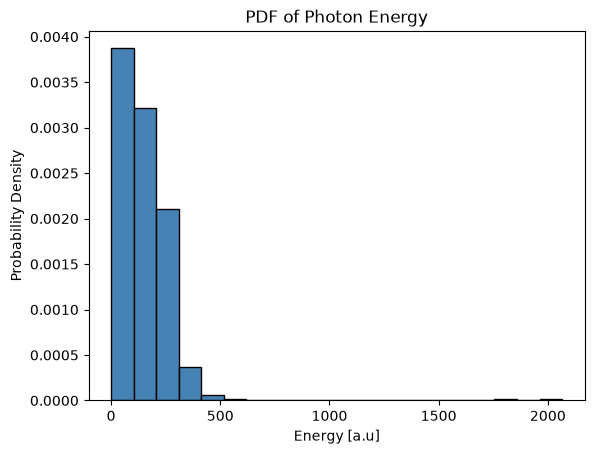

In [90]:
hist, binEdges, _ = plt.hist(df[0], bins=20, density=True, edgecolor="black", color="steelblue")
plt.xlabel("Energy [a.u]")
plt.ylabel("Probability Density")
plt.title("PDF of Photon Energy")
plt.show()

In [77]:
E = df[0]
Eb = 100

def signal(ns, G, E0, E) -> np.array:
    return (ns/N_photons)*1/(np.pi*G*(1 + ((E-E0)/G)**2))

def background(nb, E) -> np.array:
    return (nb/N_photons)*(1/Eb)*(np.exp(-E/Eb))

def complete_pdf(x, E):
    ns, nb, E0 ,G = x
    return signal(ns,G,E0, E) + background(nb, E)

def liklihood(x, E) -> float:
    return -2*np.sum(np.log(complete_pdf(x,E)))

def total_photons_constraint(x):
    return x[0] + x[1] - N_photons

In [78]:
ns_bound = [0,N_photons]
nb_bound = [0,N_photons]
E0_bound = [0,np.inf]
G_bound = [0,np.inf]

ns_init = N_photons/2
nb_init = N_photons/2
E0_init = 100
G_init = 10
init_vals = [ns_init, nb_init, E0_init, G_init]

bound_arr = [ns_bound,nb_bound, E0_bound, G_bound]

cons = {'type':'eq', 'fun': total_photons_constraint}

In [88]:
min_params = minimize(liklihood, x0=init_vals, args=E ,method="SLSQP", bounds=bound_arr, constraints=cons)
print(min_params.x)

[180.17350994 292.82649006 206.00241833  21.84041823]


In [101]:
Energy_centers = (binEdges[1:] + binEdges[:-1])/2
ns, nb, E0 ,G = min_params.x
pred_total = complete_pdf(min_params.x,Energy_centers)
pred_signal = signal(ns,G,E0,Energy_centers)
pred_background = background(nb, Energy_centers)

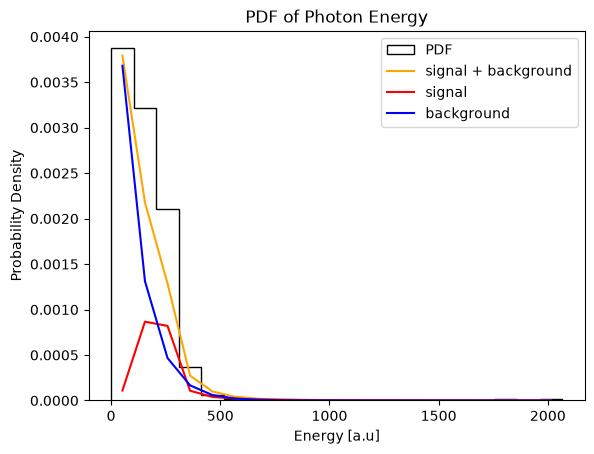

In [102]:
plt.hist(df[0], bins=20, density=True, edgecolor="black", histtype="step", label="PDF")
plt.plot(Energy_centers, pred_total, color="orange", label="signal + background")
plt.plot(Energy_centers, pred_signal, color="red", label="signal")
plt.plot(Energy_centers, pred_background, color="blue", label="background")
plt.xlabel("Energy [a.u]")
plt.ylabel("Probability Density")
plt.title("PDF of Photon Energy")
plt.legend()
plt.show()